# Previsão de Demanda com SARIMA
**Experimento completo:** validação cruzada temporal, grid search de hiperparâmetros e avaliação de métricas

---
### Estrutura do notebook
1. Instalação e importações
2. Carregamento e preparação dos dados
3. Análise exploratória (EDA)
4. Testes de estacionariedade
5. Identificação de parâmetros (ACF / PACF)
6. Grid Search de hiperparâmetros SARIMA
7. Validação cruzada temporal (Walk-Forward)
8. Modelo final e previsão
9. Avaliação de métricas
10. Exportação dos resultados

## 1. Instalação e importações

In [22]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from itertools import product

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Estilo dos gráficos
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = ['#3B8BD4', '#D85A30', '#1D9E75', '#534AB7', '#888780']

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento e preparação dos dados

In [79]:
df = pd.read_csv("../../data/raw/demand.csv",
    usecols=['date', 'sales'],
    index_col="date",
    parse_dates=["date"]
)
df = df.resample('ME').sum(numeric_only=True)

print(f'Período: {df.index[0].strftime("%b/%Y")} → {df.index[-1].strftime("%b/%Y")}')
print(f'Observações: {len(df)}')
print(f'\nEstatísticas descritivas:')
df['sales'].describe().apply(lambda x: f'{x:,.0f}')

Período: Jan/2013 → Dec/2017
Observações: 60

Estatísticas descritivas:


count           60
mean       795,075
std        172,902
min        454,904
25%        661,705
50%        799,018
75%        922,026
max      1,171,393
Name: sales, dtype: str

## 3. Análise Exploratória (EDA)

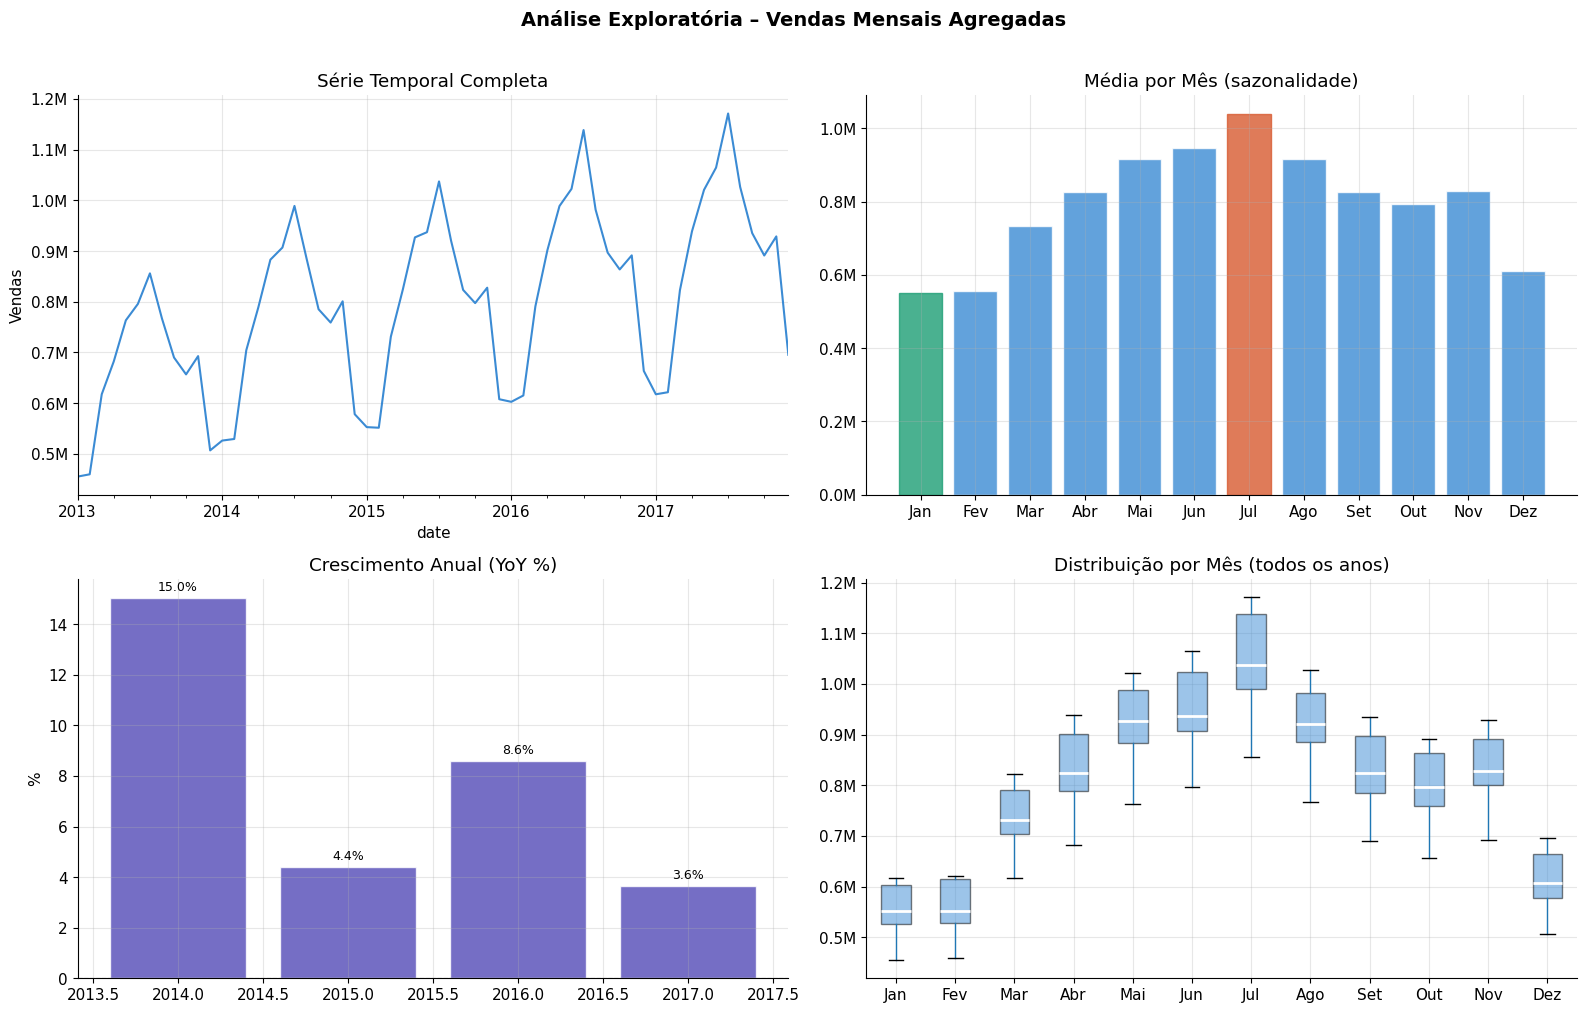

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análise Exploratória – Vendas Mensais Agregadas', fontsize=14, fontweight='bold', y=1.01)

# 1. Série completa
ax = axes[0, 0]
df['sales'].plot(ax=ax, color=PALETTE[0], linewidth=1.5)
ax.set_title('Série Temporal Completa')
ax.set_ylabel('Vendas')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# 2. Sazonalidade por mês
ax = axes[0, 1]
df['month'] = df.index.month
df['year']  = df.index.year
monthly_avg = df.groupby('month')['sales'].mean()
bars = ax.bar(range(1, 13), monthly_avg.values, color=PALETTE[0], alpha=0.8, edgecolor='white')
bars[monthly_avg.values.argmax()].set_color(PALETTE[1])
bars[monthly_avg.values.argmin()].set_color(PALETTE[2])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
ax.set_title('Média por Mês (sazonalidade)')  
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# 3. Crescimento YoY
ax = axes[1, 0]
annual = df.groupby('year')['sales'].sum()
yoy = annual.pct_change() * 100
ax.bar(yoy.index[1:], yoy.values[1:], color=PALETTE[3], alpha=0.8, edgecolor='white')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Crescimento Anual (YoY %)')
ax.set_ylabel('%')
for i, (yr, v) in enumerate(zip(yoy.index[1:], yoy.values[1:])):
    ax.text(yr, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# 4. Box-plot por mês
ax = axes[1, 1]
pivot = df.pivot_table(index='year', columns='month', values='sales')
pivot.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor=PALETTE[0], alpha=0.5),
              medianprops=dict(color='white', linewidth=2))
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
ax.set_title('Distribuição por Mês (todos os anos)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

df.drop(columns=['month', 'year'], inplace=True, errors='ignore')
plt.tight_layout()
plt.show()

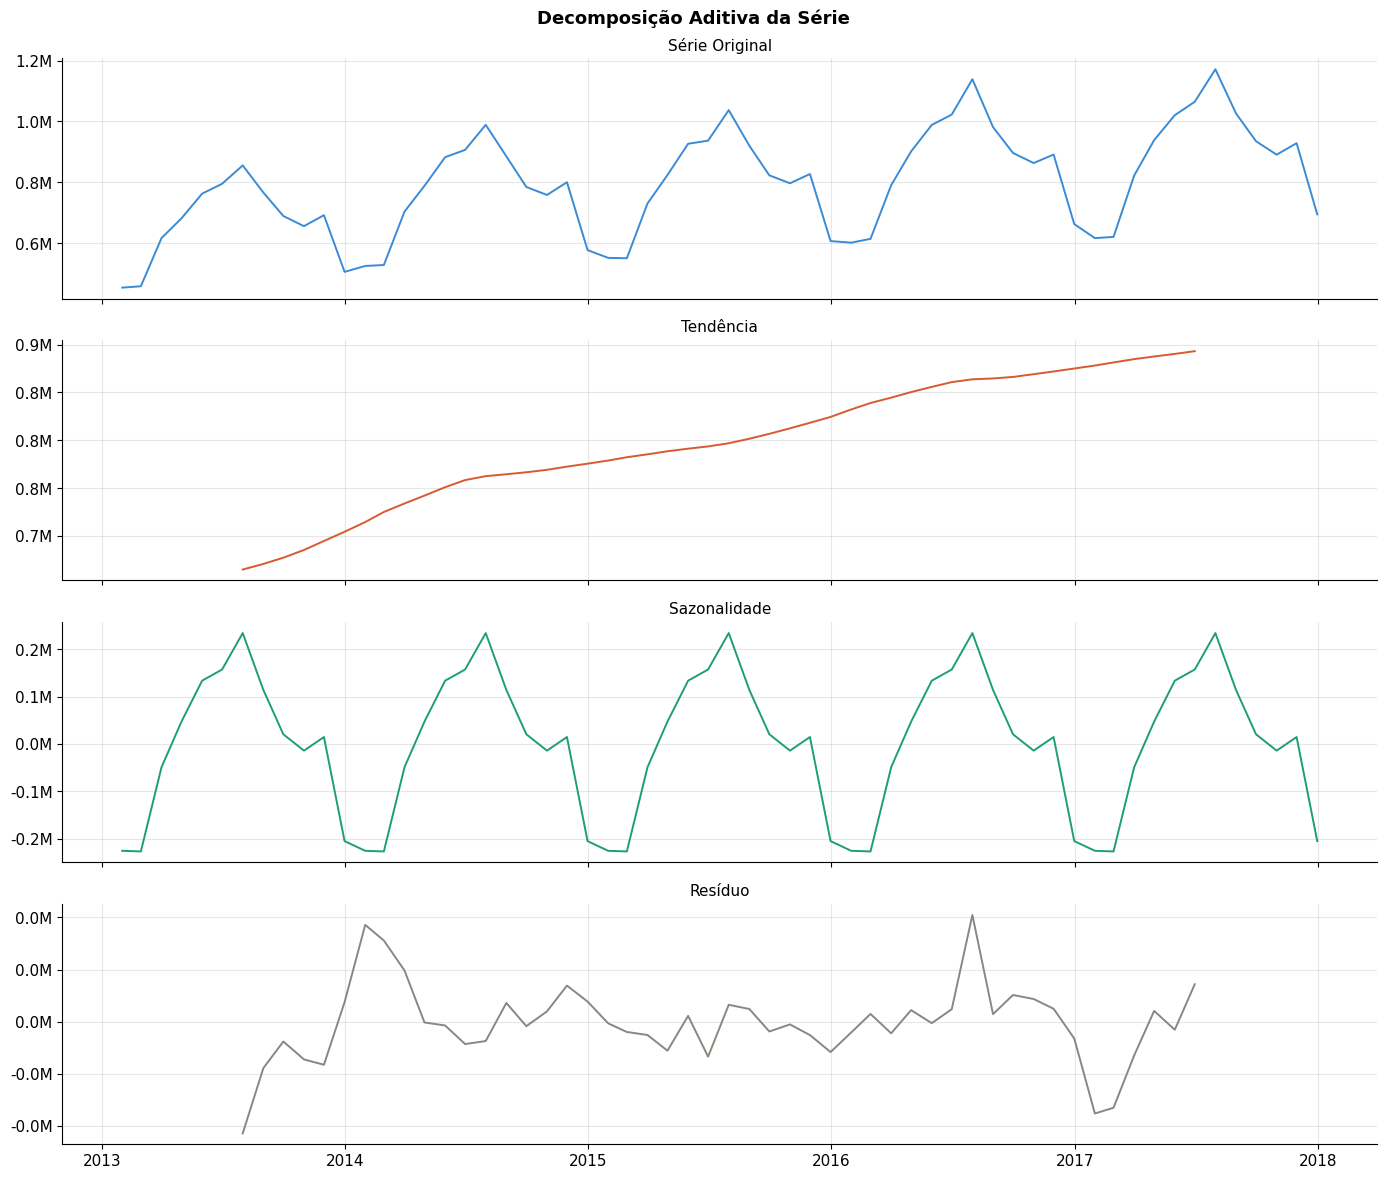

In [63]:
# Decomposição STL
decomp = seasonal_decompose(df['sales'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Decomposição Aditiva da Série', fontsize=13, fontweight='bold')

components = [
    (decomp.observed,  'Série Original',   PALETTE[0]),
    (decomp.trend,     'Tendência',         PALETTE[1]),
    (decomp.seasonal,  'Sazonalidade',      PALETTE[2]),
    (decomp.resid,     'Resíduo',           PALETTE[4]),
]
for ax, (series, title, color) in zip(axes, components):
    ax.plot(series, color=color, linewidth=1.4)
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

## 4. Testes de Estacionariedade

In [64]:
def test_stationarity(series, label='Série'):
    """Aplica ADF e KPSS e exibe resultado formatado."""
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c', nlags='auto')

    estac_adf  = 'Estacionária ✓' if adf_p < 0.05 else 'Não estacionária ✗'
    estac_kpss = 'Estacionária ✓' if kpss_p > 0.05 else 'Não estacionária ✗'

    print(f"\n{'='*55}")
    print(f" {label}")
    print(f"{'='*55}")
    print(f" ADF  → estatística: {adf_stat:8.4f}  p-valor: {adf_p:.4f}  → {estac_adf}")
    print(f" KPSS → estatística: {kpss_stat:8.4f}  p-valor: {kpss_p:.4f}  → {estac_kpss}")
    return adf_p < 0.05

# Nível original
is_stationary = test_stationarity(df['sales'], 'Série Original (nível)')

# 1ª diferença
df['sales_diff1'] = df['sales'].diff()
test_stationarity(df['sales_diff1'].dropna(), '1ª Diferença')

# 1ª diferença sazonal (lag=12)
df['sales_diff1_12'] = df['sales'].diff().diff(12)
test_stationarity(df['sales_diff1_12'].dropna(), '1ª Diferença + Diferença Sazonal (lag=12)')


 Série Original (nível)
 ADF  → estatística:  -5.2475  p-valor: 0.0000  → Estacionária ✓
 KPSS → estatística:   0.5360  p-valor: 0.0335  → Não estacionária ✗

 1ª Diferença
 ADF  → estatística:  -1.5290  p-valor: 0.5191  → Não estacionária ✗
 KPSS → estatística:   0.0777  p-valor: 0.1000  → Estacionária ✓

 1ª Diferença + Diferença Sazonal (lag=12)
 ADF  → estatística:  -6.5854  p-valor: 0.0000  → Estacionária ✓
 KPSS → estatística:   0.0605  p-valor: 0.1000  → Estacionária ✓


np.True_

## 5. ACF e PACF para identificação de parâmetros

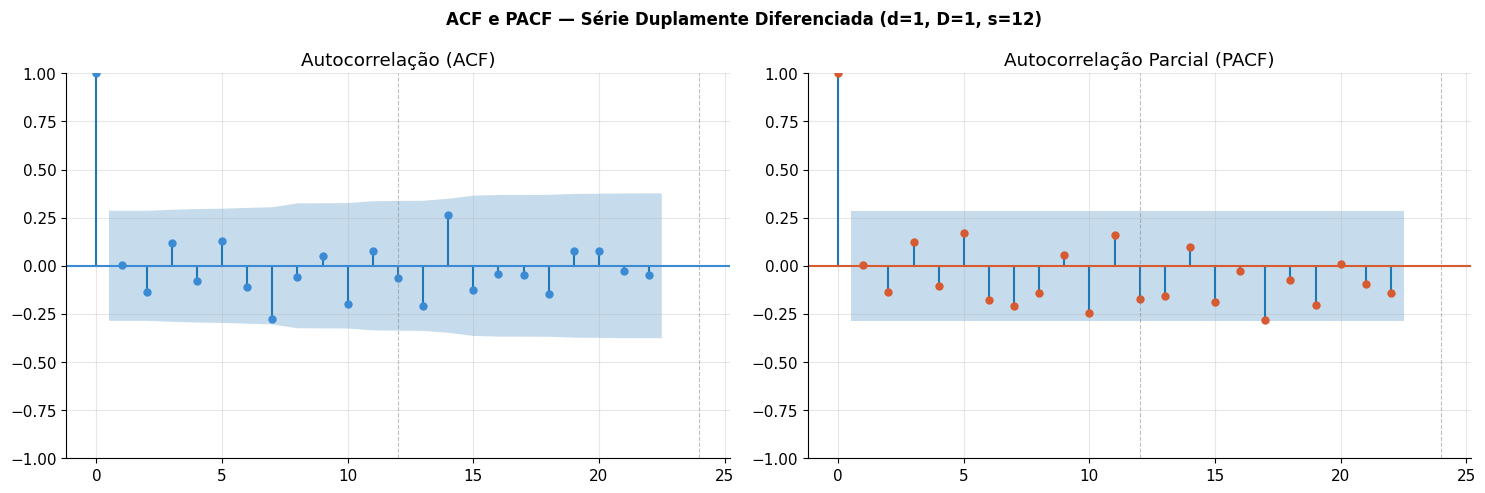


Interpretação:
  • ACF corta no lag 1  → MA(1) sugerido
  • PACF decai lentamente → AR pode ser necessário
  • Spikes nos lags 12/24 → componente sazonal (P, Q)



In [65]:
series_for_acf = df['sales_diff1_12'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF e PACF — Série Duplamente Diferenciada (d=1, D=1, s=12)', fontsize=12, fontweight='bold')

plot_acf(series_for_acf,  ax=axes[0], lags=22, color=PALETTE[0], title='Autocorrelação (ACF)')
plot_pacf(series_for_acf, ax=axes[1], lags=22, color=PALETTE[1], method='ywm', title='Autocorrelação Parcial (PACF)')

for ax in axes:
    ax.axvline(12, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axvline(24, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.show()

print("""
Interpretação:
  • ACF corta no lag 1  → MA(1) sugerido
  • PACF decai lentamente → AR pode ser necessário
  • Spikes nos lags 12/24 → componente sazonal (P, Q)
""")

## 6. Grid Search de Hiperparâmetros SARIMA

In [66]:
# Espaço de busca — ajuste conforme necessidade e tempo disponível
# SARIMA(p,d,q)(P,D,Q)[s]
p_values = [0, 1, 2]
d_values = [1]          # d=1 indicado pelos testes
q_values = [0, 1, 2]
P_values = [0, 1, 2]
D_values = [1]          # D=1 para sazonalidade
Q_values = [0, 1, 2]
s = 12                  # sazonalidade anual

train = df['sales']

results = []
grid = list(product(p_values, d_values, q_values, P_values, D_values, Q_values))
total = len(grid)

print(f'Iniciando grid search: {total} combinações\n')

for i, (p, d, q, P, D, Q) in enumerate(grid):
    try:
        model = SARIMAX(
            train,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        results.append({
            'order': (p, d, q),
            'seasonal_order': (P, D, Q, s),
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'params': f'({p},{d},{q})({P},{D},{Q})[{s}]'
        })
    except Exception:
        pass

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{total} combinações testadas...')

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print(f'\nGrid search concluído! Top 10 modelos por AIC:\n')
print(results_df[['params', 'AIC', 'BIC']].head(10).to_string(index=False))

Iniciando grid search: 81 combinações

  10/81 combinações testadas...
  20/81 combinações testadas...
  30/81 combinações testadas...
  40/81 combinações testadas...
  50/81 combinações testadas...
  60/81 combinações testadas...
  70/81 combinações testadas...
  80/81 combinações testadas...

Grid search concluído! Top 10 modelos por AIC:

            params    AIC    BIC
(1,1,2)(0,1,1)[12] 354.52 361.85
(0,1,2)(1,1,2)[12] 441.66 447.64
(0,1,2)(0,1,2)[12] 442.52 447.49
(2,1,2)(1,1,2)[12] 443.56 451.53
(2,1,2)(0,1,2)[12] 443.57 450.54
(0,1,2)(2,1,2)[12] 444.42 451.39
(1,1,2)(0,1,2)[12] 444.44 450.42
(2,1,2)(2,1,2)[12] 444.78 453.74
(1,1,2)(1,1,2)[12] 445.01 451.98
(1,1,2)(2,1,2)[12] 446.40 454.37


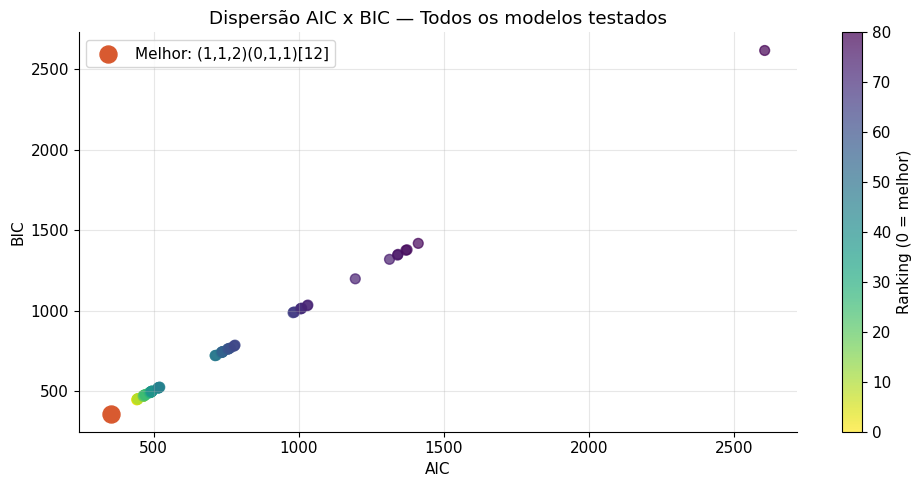


Modelo selecionado: SARIMA(1, 1, 2)(0, 1, 1, 12)


In [67]:
# Visualizar dispersão AIC x BIC
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(results_df['AIC'], results_df['BIC'],
                c=range(len(results_df)), cmap='viridis_r', alpha=0.7, s=50)
best = results_df.iloc[0]
ax.scatter(best['AIC'], best['BIC'], color=PALETTE[1], s=150, zorder=5,
           label=f'Melhor: {best["params"]}')
ax.set_xlabel('AIC')
ax.set_ylabel('BIC')
ax.set_title('Dispersão AIC x BIC — Todos os modelos testados')
ax.legend()
plt.colorbar(sc, ax=ax, label='Ranking (0 = melhor)')
plt.tight_layout()
plt.show()

best_order = best['order']
best_seasonal = best['seasonal_order']
print(f"\nModelo selecionado: SARIMA{best_order}{best_seasonal}")

## 7. Validação Cruzada Temporal (Walk-Forward)

In [68]:
def walk_forward_validation(series, order, seasonal_order, n_test=12, step=1):
    """
    Walk-forward (expanding window) validation.
    Treina o modelo em dados passados e prevê `step` passos à frente.
    Repete `n_test` vezes avançando um passo de cada vez.
    """
    n = len(series)
    n_train_start = n - n_test

    actuals, predictions, dates = [], [], []

    for i in range(n_test):
        train_slice = series.iloc[:n_train_start + i]
        test_val    = series.iloc[n_train_start + i]

        model = SARIMAX(
            train_slice,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fit = model.fit(disp=False)
        pred = fit.forecast(steps=step).iloc[-1]

        actuals.append(test_val)
        predictions.append(pred)
        dates.append(series.index[n_train_start + i])

        print(f'  {series.index[n_train_start+i].strftime("%b/%Y")} | '
              f'Real: {test_val:>12,.0f} | '
              f'Previsto: {pred:>12,.0f} | '
              f'Erro: {abs(test_val - pred):>10,.0f}')

    return pd.DataFrame({'date': dates, 'actual': actuals, 'predicted': predictions}).set_index('date')


print(f'Walk-Forward Validation — SARIMA{best_order}{best_seasonal}')
print(f'{"─"*65}')
print(f'  Mês        | Real         | Previsto     | Erro abs')
print(f'{"─"*65}')

cv_results = walk_forward_validation(
    df['sales'],
    order=best_order,
    seasonal_order=best_seasonal,
    n_test=12
)
print(f'{"─"*65}')

Walk-Forward Validation — SARIMA(1, 1, 2)(0, 1, 1, 12)
─────────────────────────────────────────────────────────────────
  Mês        | Real         | Previsto     | Erro abs
─────────────────────────────────────────────────────────────────
  Jan/2017 | Real:      617,306 | Previsto:      656,709 | Erro:     39,403
  Feb/2017 | Real:      621,369 | Previsto:      638,360 | Erro:     16,991
  Mar/2017 | Real:      822,667 | Previsto: -30,815,055,669,056,847,451,013,412,552,704 | Erro: 30,815,055,669,056,847,451,013,412,552,704
  Apr/2017 | Real:      938,862 | Previsto:      913,492 | Erro:     25,370
  May/2017 | Real:    1,020,686 | Previsto:      611,608 | Erro:    409,078
  Jun/2017 | Real:    1,064,624 | Previsto:    1,151,253 | Erro:     86,629
  Jul/2017 | Real:    1,171,393 | Previsto:    1,019,236 | Erro:    152,157
  Aug/2017 | Real:    1,026,403 | Previsto:    3,289,432 | Erro:  2,263,029
  Sep/2017 | Real:      935,263 | Previsto: -12,355,651,316,675,913,008,435,498,582,016 

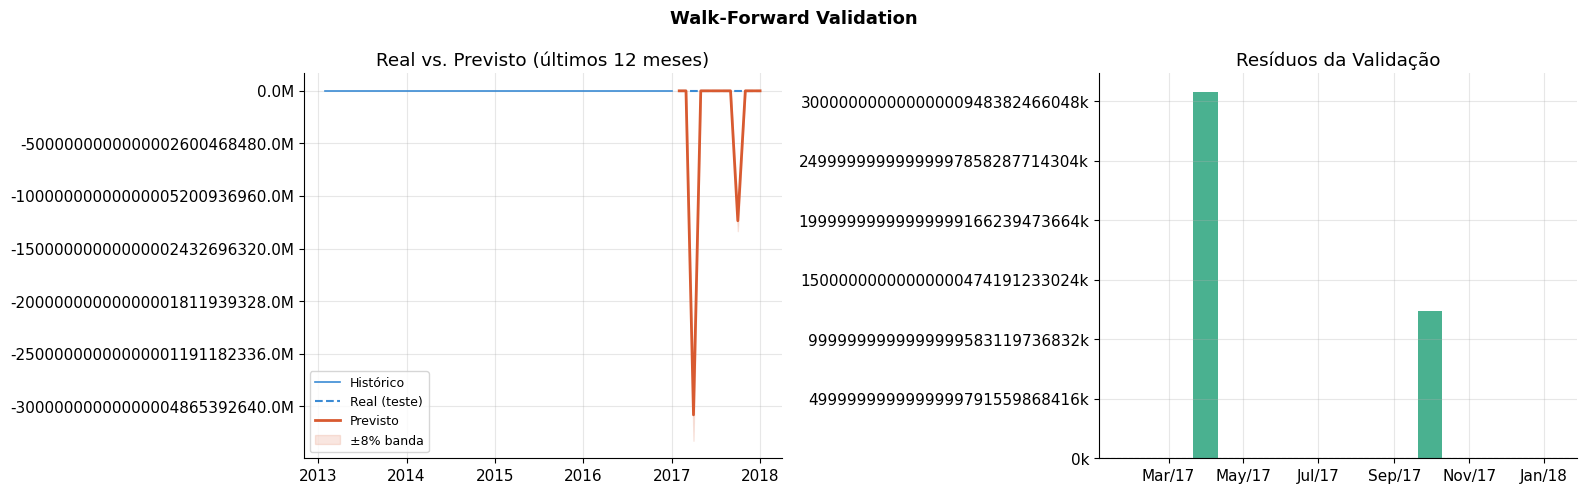

In [69]:
# Visualização da validação cruzada
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Walk-Forward Validation', fontsize=13, fontweight='bold')

# Gráfico 1: real vs previsto
ax = axes[0]
ax.plot(df['sales'].iloc[:-12], color=PALETTE[0], linewidth=1.2, label='Histórico')
ax.plot(cv_results['actual'],    color=PALETTE[0], linewidth=1.5, linestyle='--', label='Real (teste)')
ax.plot(cv_results['predicted'], color=PALETTE[1], linewidth=2,   linestyle='-',  label='Previsto')
ax.fill_between(cv_results.index,
                cv_results['predicted'] * 0.92,
                cv_results['predicted'] * 1.08,
                alpha=0.15, color=PALETTE[1], label='±8% banda')
ax.set_title('Real vs. Previsto (últimos 12 meses)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(fontsize=9)

# Gráfico 2: resíduos do CV
ax = axes[1]
residuals = cv_results['actual'] - cv_results['predicted']
colors = [PALETTE[1] if r < 0 else PALETTE[2] for r in residuals]
ax.bar(cv_results.index, residuals, color=colors, alpha=0.8, width=20)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Resíduos da Validação')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))

plt.tight_layout()
plt.show()

## 8. Modelo Final e Previsão

In [70]:
# Treinar modelo final com todos os dados
FORECAST_HORIZON = 12  # meses à frente

final_model = SARIMAX(
    df['sales'],
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_fit = final_model.fit(disp=False)

print(final_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                sales   No. Observations:                   60
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -172.261
Date:                              Sat, 21 Mar 2026   AIC                            354.522
Time:                                      17:25:07   BIC                            361.851
Sample:                                  01-31-2013   HQIC                           356.951
                                       - 12-31-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -8.6374   6150.106     -0.001      0.999   -1.21e+04     1.2e+04
ma.L1         -3.66

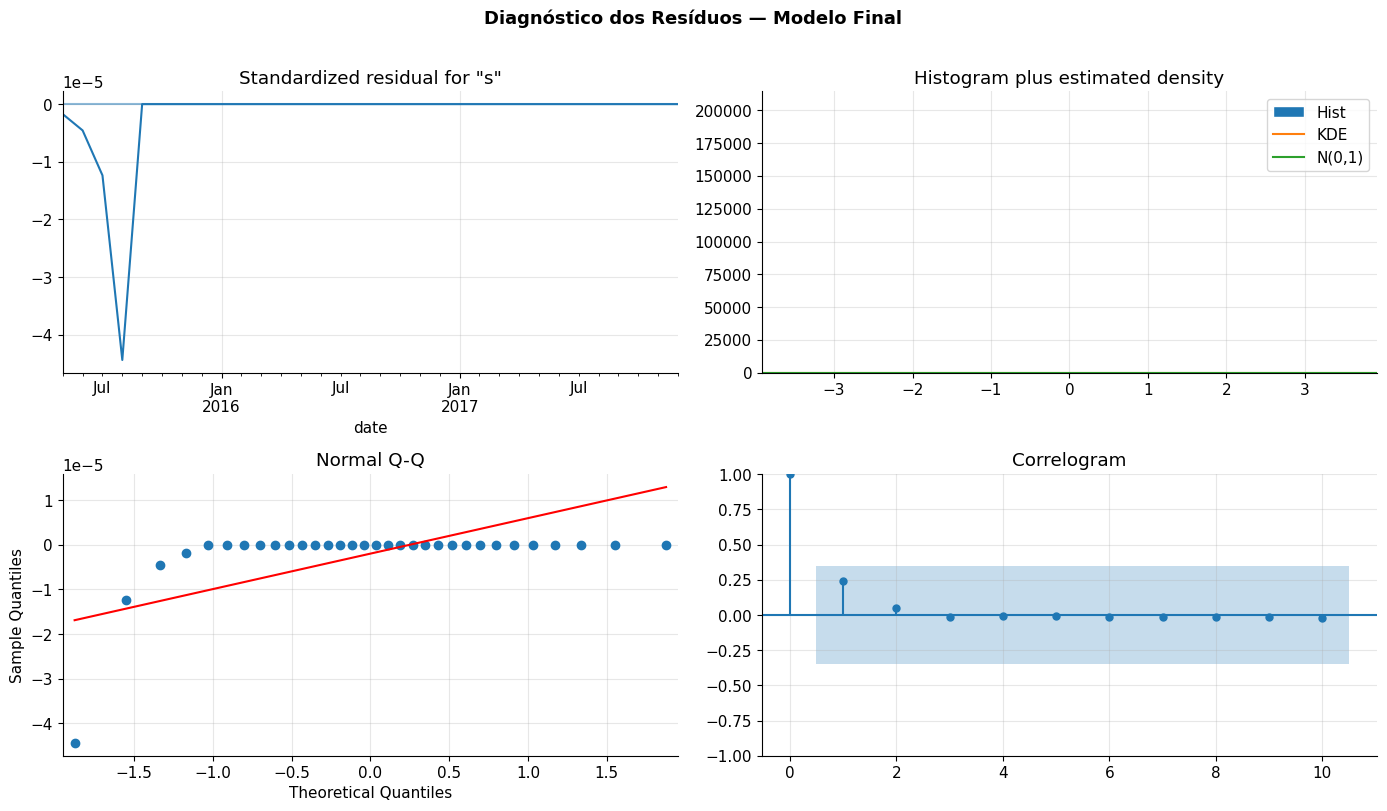

In [71]:
# Diagnóstico dos resíduos
final_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('Diagnóstico dos Resíduos — Modelo Final', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [72]:
# Gerar previsão com intervalo de confiança
forecast = final_fit.get_forecast(steps=FORECAST_HORIZON)
forecast_df = pd.DataFrame({
    'forecast':  forecast.predicted_mean,
    'lower_95':  forecast.conf_int(alpha=0.05).iloc[:, 0],
    'upper_95':  forecast.conf_int(alpha=0.05).iloc[:, 1],
    'lower_80':  forecast.conf_int(alpha=0.20).iloc[:, 0],
    'upper_80':  forecast.conf_int(alpha=0.20).iloc[:, 1],
})

# Garantir que não haja previsões negativas
forecast_df = forecast_df.clip(lower=0)

print(f"Previsão para os próximos {FORECAST_HORIZON} meses:\n")
display_df = forecast_df[['forecast', 'lower_95', 'upper_95']].copy()
display_df.index = display_df.index.strftime('%b/%Y')
display_df.columns = ['Previsão', 'IC 95% Inferior', 'IC 95% Superior']
print(display_df.map(lambda x: f'{x:>12,.0f}').to_string())

Previsão para os próximos 12 meses:

                                                                     Previsão IC 95% Inferior IC 95% Superior
Jan/2018               56,105,728,602,268,568,843,246,924,010,804,939,325,440             nan             nan
Feb/2018                                                                    0             nan             nan
Mar/2018            4,185,707,607,767,842,196,456,828,833,679,385,672,286,208             nan             nan
Apr/2018                                                                    0             nan             nan
May/2018          312,270,219,355,411,547,545,183,504,769,387,874,696,036,352             nan             nan
Jun/2018                                                                    0             nan             nan
Jul/2018       23,296,584,241,888,432,608,754,786,364,544,146,592,044,679,168             nan             nan
Aug/2018                                                                    0      

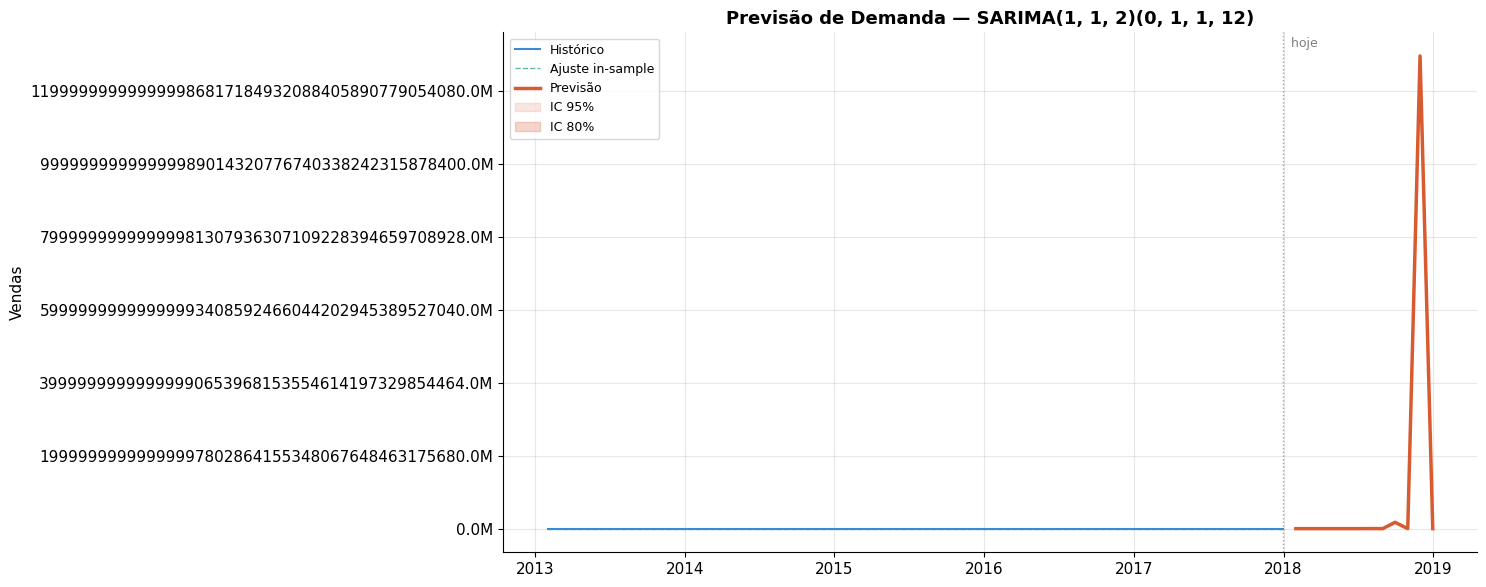

In [73]:
# Gráfico final da previsão
fig, ax = plt.subplots(figsize=(15, 6))

# Histórico
ax.plot(df['sales'], color=PALETTE[0], linewidth=1.5, label='Histórico', zorder=3)

# Fitted in-sample
fitted = final_fit.fittedvalues
ax.plot(fitted, color=PALETTE[2], linewidth=1, linestyle='--', alpha=0.7, label='Ajuste in-sample', zorder=2)

# Forecast + intervalos
ax.plot(forecast_df['forecast'], color=PALETTE[1], linewidth=2.5, label='Previsão', zorder=4)
ax.fill_between(forecast_df.index,
                forecast_df['lower_95'], forecast_df['upper_95'],
                alpha=0.15, color=PALETTE[1], label='IC 95%')
ax.fill_between(forecast_df.index,
                forecast_df['lower_80'], forecast_df['upper_80'],
                alpha=0.25, color=PALETTE[1], label='IC 80%')

# Linha vertical separando histórico de futuro
ax.axvline(df.index[-1], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(df.index[-1], ax.get_ylim()[1]*0.97, '  hoje', color='gray', fontsize=9)

ax.set_title(f'Previsão de Demanda — SARIMA{best_order}{best_seasonal}', fontsize=13, fontweight='bold')
ax.set_ylabel('Vendas')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Avaliação de Métricas

In [74]:
def evaluate(actual, predicted, label='Modelo'):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual - predicted) / actual)) * 100
    smape = np.mean(2 * np.abs(actual - predicted) / (np.abs(actual) + np.abs(predicted))) * 100
    r2    = 1 - np.sum((actual - predicted)**2) / np.sum((actual - np.mean(actual))**2)
    return {'Modelo': label, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'sMAPE (%)': smape, 'R²': r2}

# Métricas Walk-Forward (out-of-sample)
metrics_cv = evaluate(cv_results['actual'], cv_results['predicted'], f'SARIMA{best_order}{best_seasonal} — CV')

# Métricas in-sample
metrics_is = evaluate(df['sales'], final_fit.fittedvalues, f'SARIMA{best_order}{best_seasonal} — In-sample')

# Naïve sazonal como baseline
naive_pred = df['sales'].shift(12).iloc[-12:]
metrics_naive = evaluate(cv_results['actual'], naive_pred.values, 'Naïve Sazonal (baseline)')

metrics_table = pd.DataFrame([metrics_naive, metrics_cv, metrics_is]).set_index('Modelo')
metrics_table['MAE']  = metrics_table['MAE'].map('{:,.0f}'.format)
metrics_table['RMSE'] = metrics_table['RMSE'].map('{:,.0f}'.format)
metrics_table['MAPE (%)']  = metrics_table['MAPE (%)'].map('{:.2f}%'.format)
metrics_table['sMAPE (%)'] = metrics_table['sMAPE (%)'].map('{:.2f}%'.format)
metrics_table['R²']   = metrics_table['R²'].map('{:.4f}'.format)

print('Comparação de Métricas\n')
print(metrics_table.to_string())

Comparação de Métricas

                                                                                          MAE                                                 RMSE                                 MAPE (%) sMAPE (%)                                                                          R²
Modelo                                                                                                                                                                                                                                                                           
Naïve Sazonal (baseline)                                                               31,382                                               33,094                                    3.44%     3.50%                                                                      0.9614
SARIMA(1, 1, 2)(0, 1, 1, 12) — CV                   3,597,558,915,478,798,892,598,971,858,944            9,583,970,016,588,236,609,030,981,681,152        

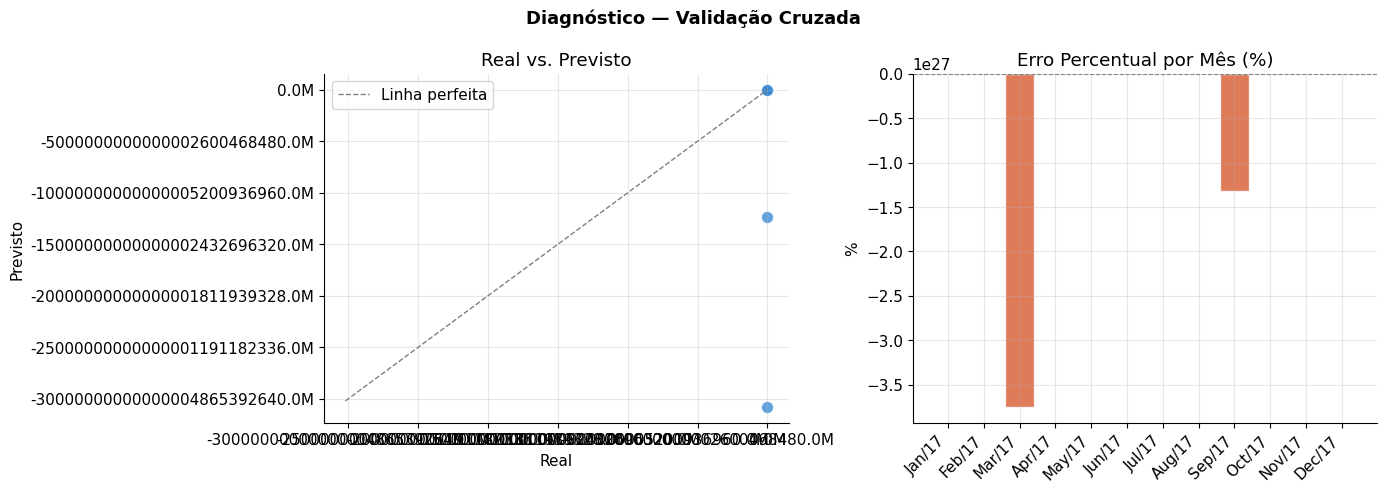

In [75]:
# Gráfico de dispersão real x previsto (validação)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diagnóstico — Validação Cruzada', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(cv_results['actual'], cv_results['predicted'],
           color=PALETTE[0], alpha=0.8, s=80, edgecolors='white')
lims = [min(cv_results['actual'].min(), cv_results['predicted'].min()) * 0.98,
         max(cv_results['actual'].max(), cv_results['predicted'].max()) * 1.02]
ax.plot(lims, lims, '--', color='gray', linewidth=1, label='Linha perfeita')
ax.set_xlabel('Real')
ax.set_ylabel('Previsto')
ax.set_title('Real vs. Previsto')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()

ax = axes[1]
erros_pct = ((cv_results['predicted'] - cv_results['actual']) / cv_results['actual'] * 100)
ax.bar(range(len(erros_pct)), erros_pct.values,
       color=[PALETTE[1] if e < 0 else PALETTE[2] for e in erros_pct],
       alpha=0.8, edgecolor='white')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xticks(range(len(erros_pct)))
ax.set_xticklabels(cv_results.index.strftime('%b/%y'), rotation=45, ha='right')
ax.set_title('Erro Percentual por Mês (%)')
ax.set_ylabel('%')

plt.tight_layout()
plt.show()

## 10. Exportação dos Resultados

In [77]:
# Exportar previsão final para CSV
output = forecast_df.copy()
output.index.name = 'date'
output.columns = ['forecast', 'lower_95', 'upper_95', 'lower_80', 'upper_80']
#output = output.round(0).astype(int)
#output.to_csv('sarima_forecast.csv')

print('Arquivo salvo: sarima_forecast.csv')
print(f'\nResumo da previsão para os próximos {FORECAST_HORIZON} meses:')
print(f'  Mínimo esperado : {output["forecast"].min():>12,}')
print(f'  Máximo esperado : {output["forecast"].max():>12,}')
print(f'  Total previsto  : {output["forecast"].sum():>12,}')
print(f'\nModelo utilizado : SARIMA{best_order}{best_seasonal}')
print(f'AIC              : {best["AIC"]:.2f}')
print(f'BIC              : {best["BIC"]:.2f}')

Arquivo salvo: sarima_forecast.csv

Resumo da previsão para os próximos 12 meses:
  Mínimo esperado :          0.0
  Máximo esperado : 1.29662864250767e+50
  Total previsto  : 1.314244939867958e+50

Modelo utilizado : SARIMA(1, 1, 2)(0, 1, 1, 12)
AIC              : 354.52
BIC              : 361.85


---
## Próximos Passos Sugeridos

| Experimento | Descrição |
|---|---|
| **Prophet** | Comparar com o modelo do Meta (lida bem com feriados e outliers) |
| **SARIMAX com exógenas** | Incluir variáveis externas (temperatura, promoções, feriados) |
| **Ensemble** | Média ponderada SARIMA + Holt-Winters para reduzir variância |
| **Nível de loja/item** | Treinar modelos individuais por loja e por item |
| **Detecção de outliers** | Remover anomalias antes de treinar para melhorar estabilidade |
| **Previsão hierárquica** | Reconciliação bottom-up / top-down entre loja, item e total |